In [10]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [11]:
base_dir = "../data/raw/dogs-vs-cats/dogs-vs-cats/"
train_dir = os.path.join(base_dir, "train")

print("train contiene:", os.listdir(train_dir))

train contiene: ['cat.12256.jpg', 'cat.11465.jpg', 'dog.3873.jpg', 'cat.8846.jpg', 'cat.9903.jpg', 'cat.11865.jpg', 'dog.1011.jpg', 'cat.928.jpg', 'cat.2880.jpg', 'dog.5454.jpg', 'cat.5750.jpg', 'dog.7426.jpg', 'cat.2959.jpg', 'cat.2591.jpg', 'dog.6624.jpg', 'cat.2229.jpg', 'dog.3762.jpg', 'dog.6537.jpg', 'dog.139.jpg', 'dog.186.jpg', 'dog.4575.jpg', 'dog.7836.jpg', 'dog.6101.jpg', 'dog.12010.jpg', 'cat.11530.jpg', 'cat.2636.jpg', 'dog.10485.jpg', 'cat.1081.jpg', 'cat.4230.jpg', 'dog.5288.jpg', 'cat.4136.jpg', 'dog.7441.jpg', 'dog.3353.jpg', 'dog.6279.jpg', 'cat.4583.jpg', 'dog.7802.jpg', 'dog.5745.jpg', 'dog.6504.jpg', 'cat.10771.jpg', 'cat.5947.jpg', 'dog.5466.jpg', 'cat.4903.jpg', 'dog.9846.jpg', 'dog.9061.jpg', 'dog.10242.jpg', 'dog.6930.jpg', 'cat.1094.jpg', 'cat.2200.jpg', 'cat.4883.jpg', 'cat.11707.jpg', 'dog.5030.jpg', 'dog.1835.jpg', 'dog.6416.jpg', 'dog.1522.jpg', 'dog.3779.jpg', 'dog.4903.jpg', 'dog.8592.jpg', 'cat.10644.jpg', 'dog.3557.jpg', 'dog.11629.jpg', 'cat.7979.jpg',

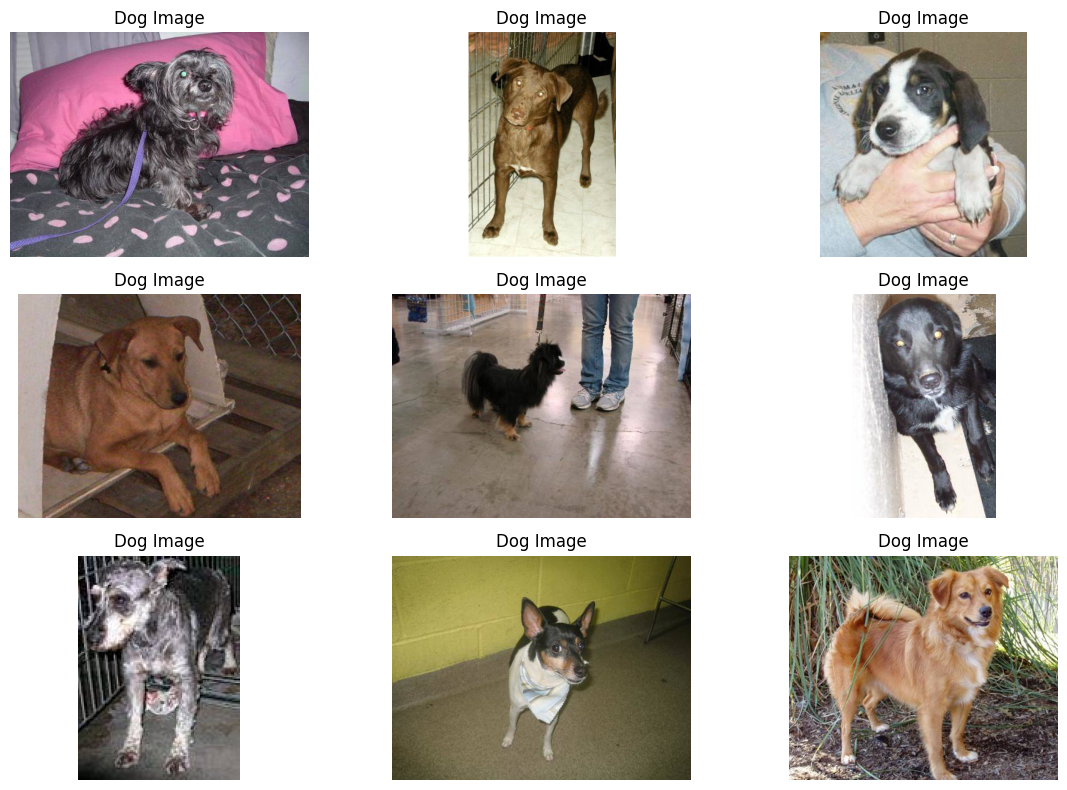

In [12]:
data_dir = "../data/raw/dogs-vs-cats/"


dog_subfolder = "../data/raw/dogs-vs-cats/dogs-vs-cats/train"
dog_image_files = sorted([f for f in os.listdir(dog_subfolder) if f.startswith("dog.")])


dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  
    img_array = image.img_to_array(img)
    img_array /= 255.0  
    dog_images.append(img_array)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

plt.tight_layout()


plt.show()

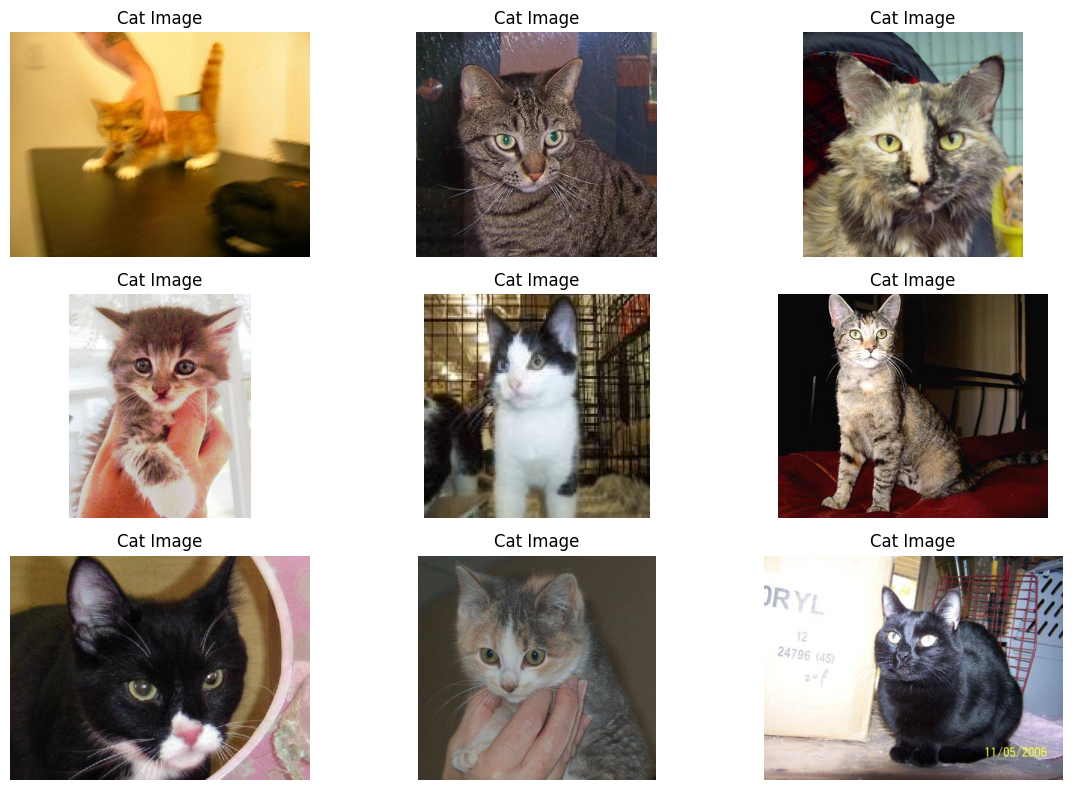

In [13]:
data_dir = "../data/raw/dogs-vs-cats/"

cats_subfolder = "../data/raw/dogs-vs-cats/dogs-vs-cats/train"


cats_image_files = sorted([f for f in os.listdir(dog_subfolder) if f.startswith("cat.")])

cats_images = []
for i in range(min(9, len(cats_image_files))):  
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')


plt.tight_layout()
plt.show()


In [14]:
src_train = "../data/raw/dogs-vs-cats/dogs-vs-cats/train"
dst_root  = "../data/processed/dogs-vs-cats/train"

dog_dir = os.path.join(dst_root, "dog")
cat_dir = os.path.join(dst_root, "cat")
os.makedirs(dog_dir, exist_ok=True)
os.makedirs(cat_dir, exist_ok=True)

for f in os.listdir(src_train):
    f_low = f.lower()
    if f_low.startswith("dog.") and f_low.endswith(".jpg"):
        shutil.copy2(os.path.join(src_train, f), os.path.join(dog_dir, f))
    elif f_low.startswith("cat.") and f_low.endswith(".jpg"):
        shutil.copy2(os.path.join(src_train, f), os.path.join(cat_dir, f))

print("Dogs:", len(os.listdir(dog_dir)))
print("Cats:", len(os.listdir(cat_dir)))

Dogs: 12500
Cats: 12500


In [15]:
train_dir = "../data/processed/dogs-vs-cats/train"
image_size = (200, 200)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

test_data = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
